In [1]:
import importlib
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pygpcca
# # --
# import _001_PRC_extract_trajectories
# importlib.reload(_001_PRC_extract_trajectories)
# from _001_PRC_extract_trajectories import multi_load_kap_data, multi_load_fg_data, FG_TYPES, N_CHAINS_PER_FG, N_BEADS_PER_FG
# --
import _004_PRC_interaction_chains
importlib.reload(_004_PRC_interaction_chains)
from _004_PRC_interaction_chains import categorize_multiples
# --
import _013_PRC_clustering
importlib.reload(_013_PRC_clustering)
from _013_PRC_clustering import load_embed_save, load_reduce_cluster_save, load_cluster_trajectories_save, load_embed_save_2, load_reduce_cluster_save_2
# --
import _015_PRC_clustered_chains
importlib.reload(_015_PRC_clustered_chains)
from _015_PRC_clustered_chains import generate_transition_matrix, generate_bmsm
# --
import utils
importlib.reload(utils)
from utils import mean_first_passage_time, amount_to_concentration, radius_a_to_kda, markov_rate_flux, markov_rate_manual
# --
import raveh_2025.show_transport_stats_v3
importlib.reload(raveh_2025.show_transport_stats_v3)
from raveh_2025.show_transport_stats_v3 import read_df, calc_filtered_transport_stats

In [2]:
radii = [20,30,40,50,60]
kdas = [radius_a_to_kda(r) for r in radii] 
n_sites = [2, 4, 6]
# def calc_k(radius, sites):
#     surface_area = 4 * np.pi * radius**2
#     k = sites + (surface_area // 10000)
#     print(f"Radius: {radius} Å, Sites: {sites}, k: {k:.1f}")
#     return int(k)
# for r in radii:
#     for s in n_sites:
#         calc_k(r, s)

In [ ]:
# Extract trajectories for Kaps #
#################################

# # 10-50
# for sites in n_sites:
#     for radius in radii:
#         kap_results = multi_load_kap_data(
#             input_rmf_path=f"/cs/labs/ravehb/roi.eliasian/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_variants/{sites}_sites",
#             kap_radius=radius,
#             kap_amount=50,
#             start_t=10000,
#             end_t=50000,
#             step_t=100,
#             sims_range=range(1, 31),
#             frames_per_file=1,
#             one_frame_from_each=True
#         )
#         for i, result in enumerate(kap_results):
#             os.makedirs(f"/cs/labs/ravehb/roi.eliasian/Master/NPC-markov/data/ntr_variants/{sites}_sites/{radius}_radius/single_sim_coords/{i+1}", exist_ok=True)
#             with open(f"/cs/labs/ravehb/roi.eliasian/Master/NPC-markov/data/ntr_variants/{sites}_sites/{radius}_radius/single_sim_coords/{i+1}/10-50.pickle", "wb") as f:
#                 pickle.dump(result, f)
      
# # 50-80          
# for sites in n_sites:
#     for radius in radii:
#         kap_results = multi_load_kap_data(
#             input_rmf_path=f"/cs/labs/ravehb/roi.eliasian/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_variants/{sites}_sites",
#             kap_radius=radius,
#             kap_amount=50,
#             start_t=50000,
#             end_t=80000,
#             step_t=100,
#             sims_range=range(1, 31),
#             frames_per_file=1,
#             one_frame_from_each=True
#         )
#         for i, result in enumerate(kap_results):
#             os.makedirs(f"/cs/labs/ravehb/roi.eliasian/Master/NPC-markov/data/ntr_variants/{sites}_sites/{radius}_radius/single_sim_coords/{i+1}", exist_ok=True)
#             with open(f"/cs/labs/ravehb/roi.eliasian/Master/NPC-markov/data/ntr_variants/{sites}_sites/{radius}_radius/single_sim_coords/{i+1}/50-80.pickle", "wb") as f:
#                 pickle.dump(result, f)
                
                
# sites 10-80
for sites in n_sites:
    for radius in radii:
        os.makedirs(f"/cs/labs/ravehb/roi.eliasian/Master/NPC-markov/data/ntr_variants/{sites}_sites/{radius}_radius/single_sim_site_coords", exist_ok=True)
        kap_results = multi_load_kap_data(
            input_rmf_path=f"/cs/labs/ravehb/roi.eliasian/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_variants/{sites}_sites",
            kap_radius=radius,
            kap_amount=50,
            start_t=10000,
            end_t=80000,
            step_t=100,
            sims_range=range(1, 31),
            frames_per_file=1,
            one_frame_from_each=True,
            get_nsites=sites
        )
        for i, result in enumerate(kap_results):
            os.makedirs(f"/cs/labs/ravehb/roi.eliasian/Master/NPC-markov/data/ntr_variants/{sites}_sites/{radius}_radius/single_sim_site_coords/{i+1}", exist_ok=True)
            with open(f"/cs/labs/ravehb/roi.eliasian/Master/NPC-markov/data/ntr_variants/{sites}_sites/{radius}_radius/single_sim_site_coords/{i+1}/10-80.pickle", "wb") as f:
                pickle.dump(result, f)


In [ ]:
# Extract trajectories for FGs #
################################

# 10-50
# for sites in n_sites:
#     fg_results = multi_load_fg_data(
#         input_rmf_path=f"/cs/labs/ravehb/roi.eliasian/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_variants/{sites}_sites",
#         fg_types=FG_TYPES,
#         n_chains_per_fg=N_CHAINS_PER_FG,
#         n_beads_per_fg=N_BEADS_PER_FG,
#         start_t=10000,
#         end_t=50000,
#         step_t=100,
#         sims_range=range(1, 31),
#         frames_per_file=1,
#         one_frame_from_each=True
#     )

#     for i, result in enumerate(fg_results):
#         os.makedirs(f"/cs/labs/ravehb/roi.eliasian/Master/NPC-markov/data/ntr_variants/{sites}_sites/fgs_single_sim_coords/{i+1}", exist_ok=True)
#         with open(f"/cs/labs/ravehb/roi.eliasian/Master/NPC-markov/data/ntr_variants/{sites}_sites/fgs_single_sim_coords/{i+1}/10-50-fgs.pickle", "wb") as f:
#             pickle.dump(result, f)
            
# 50-80
for sites in n_sites:
    fg_results = multi_load_fg_data(
        input_rmf_path=f"/cs/labs/ravehb/roi.eliasian/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_variants/{sites}_sites",
        fg_types=FG_TYPES,
        n_chains_per_fg=N_CHAINS_PER_FG,
        n_beads_per_fg=N_BEADS_PER_FG,
        start_t=50000,
        end_t=80000,
        step_t=100,
        sims_range=range(1, 31),
        frames_per_file=1,
        one_frame_from_each=True
    )

    for i, result in enumerate(fg_results):
        os.makedirs(f"/cs/labs/ravehb/roi.eliasian/Master/NPC-markov/data/ntr_variants/{sites}_sites/fgs_single_sim_coords/{i+1}", exist_ok=True)
        with open(f"/cs/labs/ravehb/roi.eliasian/Master/NPC-markov/data/ntr_variants/{sites}_sites/fgs_single_sim_coords/{i+1}/50-80-fgs.pickle", "wb") as f:
            pickle.dump(result, f)

Using 30 cores
Using 30 cores
Using 30 cores


In [14]:
with open(f"data/ntr_variants/{6}_sites/{20}_radius/single_sim_coords/30/50-80.pickle", "rb") as f:
    data = pickle.load(f)
print(data)

In [9]:
# Categorize trajectories to microstates (transient interactions) #
###################################################################

for sites in n_sites:
    for radius in radii:
        print(f"Categorizing diffusers for {sites} sites and {radius} A radius...")
        os.makedirs(f"data/ntr_variants/{sites}_sites/{radius}_radius/categorized", exist_ok=True)
        categorize_multiples(
            sim_indexes=range(1, 30),
            sim_times=["10-50", "50-80"],
            diffuser_coords_path_prefix=f"data/ntr_variants/{sites}_sites/{radius}_radius/single_sim_coords/",
            fg_coords_path_prefix=f"data/ntr_variants/{sites}_sites/fgs_single_sim_coords/",
            step=1,
            save_file_path=f"data/ntr_variants/{sites}_sites/{radius}_radius/categorized/10-80-5k-1dist-nmc-multi.pickle",
            k=5,
            diffuser_radius_nm=radius/10,
            max_surface_distance_nm=1,
            split_nc=True
        )
# 0.5 dist gave channel warnings (but not too many)
print("Done!")

Categorizing diffusers for 2 sites and 20 A radius...
Using 32 cores
10-50, 1 50-80, 1 10-50, 2 50-80, 2 10-50, 3 50-80, 3 10-50, 4 50-80, 4 10-50, 5 50-80, 5 10-50, 6 50-80, 6 10-50, 7 50-80, 7 10-50, 8 50-80, 8 10-50, 9 50-80, 9 10-50, 10 50-80, 10 10-50, 11 50-80, 11 10-50, 12 50-80, 12 10-50, 13 50-80, 13 10-50, 14 50-80, 14 10-50, 15 50-80, 15 10-50, 16 50-80, 16 10-50, 17 50-80, 17 10-50, 18 50-80, 18 10-50, 19 50-80, 19 10-50, 20 50-80, 20 10-50, 21 50-80, 21 10-50, 22 50-80, 22 10-50, 23 50-80, 23 10-50, 24 50-80, 24 10-50, 25 50-80, 25 10-50, 26 50-80, 26 10-50, 27 50-80, 27 10-50, 28 50-80, 28 10-50, 29 50-80, 29 
Categorizing diffusers for 2 sites and 30 A radius...
Using 32 cores
10-50, 1 50-80, 1 10-50, 2 50-80, 2 10-50, 3 50-80, 3 10-50, 4 50-80, 4 10-50, 5 50-80, 5 10-50, 6 50-80, 6 10-50, 7 50-80, 7 10-50, 8 50-80, 8 10-50, 9 50-80, 9 10-50, 10 50-80, 10 10-50, 11 50-80, 11 10-50, 12 50-80, 12 10-50, 13 50-80, 13 10-50, 14 50-80, 14 10-50, 15 50-80, 15 10-50, 16 50-80, 

In [7]:
# Embed interactions to histograms #
####################################

for sites in n_sites:
    for radius in radii:
        print(f"Embedding diffusers for {sites} sites and {radius} A radius...")
        os.makedirs(f"data/ntr_variants/{sites}_sites/{radius}_radius/embedded", exist_ok=True)
        load_embed_save_2(
            window_size=10, # 1000 ns
            load_categorized_path=f"data/ntr_variants/{sites}_sites/{radius}_radius/categorized/10-80-5k-1dist-nmc-multi.pickle",
            save_embedded_path=f"data/ntr_variants/{sites}_sites/{radius}_radius/embedded/10-80-5k-1dist-nmc-multi-sym.pickle",
            save_embedded_eighth_path=None,
            split_nc="nmc"
        )
print("Done!")

Embedding diffusers for 2 sites and 20 A radius...
Embedding diffusers for 2 sites and 30 A radius...
Embedding diffusers for 2 sites and 40 A radius...
Embedding diffusers for 2 sites and 50 A radius...
Embedding diffusers for 2 sites and 60 A radius...
Embedding diffusers for 4 sites and 20 A radius...
Embedding diffusers for 4 sites and 30 A radius...
Embedding diffusers for 4 sites and 40 A radius...
Embedding diffusers for 4 sites and 50 A radius...
Embedding diffusers for 4 sites and 60 A radius...
Embedding diffusers for 6 sites and 20 A radius...
Embedding diffusers for 6 sites and 30 A radius...
Embedding diffusers for 6 sites and 40 A radius...
Embedding diffusers for 6 sites and 50 A radius...
Embedding diffusers for 6 sites and 60 A radius...
Done!


In [6]:
with open(f"data/ntr_variants/{2}_sites/{60}_radius/clustered/10-80-5k-1dist-nmc-multi-sym-faiss-40clusters.pickle", "rb") as f:
    clustered = pickle.load(f)
    pass

KeyboardInterrupt: 

In [3]:
# Calculate mesostates #
########################

for sites in n_sites:
    for radius in radii:
        print(f"Calculating mesostates for {sites} sites and {radius} A radius...")
        os.makedirs(f"data/ntr_variants/{sites}_sites/{radius}_radius/clusterings", exist_ok=True)
        load_reduce_cluster_save_2(
            pca_components=220,
            n_clusters=[40, 80, 160, 320, 640, 1280],
            load_embedded_path=f"data/ntr_variants/{sites}_sites/{radius}_radius/embedded/10-80-5k-1dist-nmc-multi-sym.pickle",
            save_pca_cluster_path=f"data/ntr_variants/{sites}_sites/{radius}_radius/clusterings/10-80-5k-1dist-nmc-multi-sym-faiss-#c#clusters.pickle",
            save_clustered_path=f"data/ntr_variants/{sites}_sites/{radius}_radius/clustered/10-80-5k-1dist-nmc-multi-sym-faiss-#c#clusters.pickle",
            verbose=False,
            # method="faiss",
            # filter_common=False
        )
print("Done!")

Calculating mesostates for 2 sites and 20 A radius...
Reduced from 40 to 34 clusters after pruning underpopulated centroids
Reduced from 80 to 50 clusters after pruning underpopulated centroids
Reduced from 160 to 64 clusters after pruning underpopulated centroids
Reduced from 320 to 109 clusters after pruning underpopulated centroids
Reduced from 640 to 181 clusters after pruning underpopulated centroids
Reduced from 1280 to 450 clusters after pruning underpopulated centroids
Calculating mesostates for 2 sites and 30 A radius...
Reduced from 40 to 40 clusters after pruning underpopulated centroids
Reduced from 80 to 50 clusters after pruning underpopulated centroids
Reduced from 160 to 69 clusters after pruning underpopulated centroids
Reduced from 320 to 73 clusters after pruning underpopulated centroids
Reduced from 640 to 212 clusters after pruning underpopulated centroids
Reduced from 1280 to 382 clusters after pruning underpopulated centroids
Calculating mesostates for 2 sites an

In [ ]:
# # Cluster embedded trajectories to mesostates #
# ###############################################

for sites in n_sites:
    for radius in radii:
        print(f"Clustering trajectories for {sites} sites and {radius} A radius...")
        os.makedirs(f"data/ntr_variants/{sites}_sites/{radius}_radius/clustered", exist_ok=True)
        load_cluster_trajectories_save(
            n_clusters=[10, 20, 40, 80, 160, 320, 640, 1280],
            load_embedded_path=f"data/ntr_variants/{sites}_sites/{radius}_radius/embedded/10-80-6k.pickle",
            load_pca_cluster_path=f"data/ntr_variants/{6}_sites/{radius}_radius/clusterings/10-80-6k-218pca-kmeans-#c#clusters.pickle",
            save_clustered_path=f"data/ntr_variants/{sites}_sites/{radius}_radius/clustered_from_6-20/10-80-6k-218pca-kmeans-#c#clusters.pickle"
        )

Clustering trajectories for 2 sites and 20 A radius...
Clustering trajectories for 2 sites and 30 A radius...
Clustering trajectories for 2 sites and 40 A radius...
Clustering trajectories for 2 sites and 50 A radius...
Clustering trajectories for 2 sites and 60 A radius...
Clustering trajectories for 4 sites and 20 A radius...
Clustering trajectories for 4 sites and 30 A radius...
Clustering trajectories for 4 sites and 40 A radius...
Clustering trajectories for 4 sites and 50 A radius...
Clustering trajectories for 4 sites and 60 A radius...
Clustering trajectories for 6 sites and 20 A radius...
Clustering trajectories for 6 sites and 30 A radius...
Clustering trajectories for 6 sites and 40 A radius...
Clustering trajectories for 6 sites and 50 A radius...
Clustering trajectories for 6 sites and 60 A radius...


In [64]:
# 3
for sites in n_sites:
    for radius in radii:
        total_full_transports = 0
        with open(f"data/ntr_variants/{sites}_sites/{radius}_radius/categorized/10-80-sitek-05dist.pickle", "rb") as f:
            data = pickle.load(f)
        n_trajs = data.shape[0]
        for i in range(n_trajs):
            traj = data[i, 0, :]
            if "nuc" in traj and "cyt" in traj:
                total_full_transports += 1
                # print(i)
        
        
        # calc empirical permeability
        concentration_M = amount_to_concentration(50, box_side_a=800) # single molecule
        concentration_uM = concentration_M * 1e6
        
        time_us = 70
        time_s = time_us * 1e-6
        n_sims = 29
        rate = total_full_transports / (time_s * n_sims)
        emprical_permeability = rate / concentration_uM
        print(f"Total full transports for {sites} sites and {radius} radius: {total_full_transports} out of {n_trajs} ({total_full_transports/n_trajs*100:.2f}%) (Permeability: {emprical_permeability} 1 / s / uM / NPC)")

# with np.printoptions(threshold=np.inf):
#     print(data[221])



Total full transports for 2 sites and 20 radius: 12 out of 1450 (0.83%) (Permeability: 36.45323431471922 1 / s / uM / NPC)
Total full transports for 2 sites and 30 radius: 0 out of 1450 (0.00%) (Permeability: 0.0 1 / s / uM / NPC)
Total full transports for 2 sites and 40 radius: 0 out of 1450 (0.00%) (Permeability: 0.0 1 / s / uM / NPC)
Total full transports for 2 sites and 50 radius: 0 out of 1450 (0.00%) (Permeability: 0.0 1 / s / uM / NPC)
Total full transports for 2 sites and 60 radius: 0 out of 1450 (0.00%) (Permeability: 0.0 1 / s / uM / NPC)
Total full transports for 4 sites and 20 radius: 47 out of 1450 (3.24%) (Permeability: 142.7751677326503 1 / s / uM / NPC)
Total full transports for 4 sites and 30 radius: 6 out of 1450 (0.41%) (Permeability: 18.22661715735961 1 / s / uM / NPC)
Total full transports for 4 sites and 40 radius: 0 out of 1450 (0.00%) (Permeability: 0.0 1 / s / uM / NPC)
Total full transports for 4 sites and 50 radius: 0 out of 1450 (0.00%) (Permeability: 0.0 1 

In [16]:
# Generate mesostate transition matrices
# option 1: standard
# option 2: bmsm

for sites in [2,4,6]:
    for radius in [20,30,40,50,60]:
        print(f"Generating transition matrix for {sites} sites and {radius} radius")
        os.makedirs(f"data/ntr_variants/{sites}_sites/{radius}_radius/transition_matrices", exist_ok=True)
        for n_clusters in [40, 80, 160, 320, 640, 1280]:
            suffix = f"10-80-5k-1dist-nmc-multi-sym-faiss-{n_clusters}clusters.pickle"
            with open(f"data/ntr_variants/{sites}_sites/{radius}_radius/clusterings/{suffix}", "rb") as f:
                pca_cluster = pickle.load(f)
                actual_n_clusters = pca_cluster.centroids.shape[0]
            with open(f"data/ntr_variants/{sites}_sites/{radius}_radius/clustered/{suffix}", "rb") as f:
                clustered_data = pickle.load(f)
            transition_matrix = generate_transition_matrix(clustered_data[:, :], actual_n_clusters, prior = 0.01)
            with open(f"data/ntr_variants/{sites}_sites/{radius}_radius/transition_matrices/{n_clusters}clusters.pickle", "wb") as f:
                pickle.dump(transition_matrix, f)
                
# for sites in [2]:
#     for radius in [60]:
#         print(f"Generating BMSM for {sites} sites and {radius} radius")
#         os\.makedirs(f"data/ntr_variants/{sites}_sites/{radius}_radius/bmsm", exist_ok=True)
#         for n_clusters in [640]:
#             with open(f"data/ntr_variants/{sites}_sites/{radius}_radius/clustered/10-50-6k-218pca-kmeans-{n_clusters}clusters.pickle", "rb") as f:
#                 clustered_data = pickle.load(f)
#             bmsm = generate_bmsm(clustered_data, n_mesostates=n_clusters, lagtime=1, reversible=True)
#             with open(f"data/ntr_variants/{sites}_sites/{radius}_radius/bmsm/218pca-{n_clusters}clusters.pickle", "wb") as f:
#                 pickle.dump(bmsm, f)

Generating transition matrix for 2 sites and 20 radius
Generating transition matrix for 2 sites and 30 radius
Generating transition matrix for 2 sites and 40 radius
Generating transition matrix for 2 sites and 50 radius
Generating transition matrix for 2 sites and 60 radius
Generating transition matrix for 4 sites and 20 radius
Generating transition matrix for 4 sites and 30 radius
Generating transition matrix for 4 sites and 40 radius
Generating transition matrix for 4 sites and 50 radius
Generating transition matrix for 4 sites and 60 radius
Generating transition matrix for 6 sites and 20 radius
Generating transition matrix for 6 sites and 30 radius
Generating transition matrix for 6 sites and 40 radius
Generating transition matrix for 6 sites and 50 radius
Generating transition matrix for 6 sites and 60 radius


In [17]:
# Calculate permiabilities for standard tms

def mm_permiability(tm, bottom_states=None, top_states=None):
    # # remove any rows/cols that are all zero
    # nonzero_rows = np.where(tm.sum(axis=1) != 0)[0]
    # tm = tm[np.ix_(nonzero_rows, nonzero_rows)]
    # top_states = [s - len(nonzero_rows) for s in top_states if s in nonzero_rows]
    # print(tm.shape)

    lagtime = 1e-6 # in seconds
    try:
        rate_1 = markov_rate_flux(tm, start_states=bottom_states, target_states=top_states) # units: 1/lagtime (probably 1000ns)
        rate_2 = markov_rate_flux(tm, start_states=top_states, target_states=bottom_states) # units: 1/lagtime (probably 1000ns)
    except ValueError as e:
        print(f"Error calculating rates: {e}")
        return 0
    rate_s = (1/lagtime) * (rate_1 + rate_2) # units: 1/s

    concentration_M = amount_to_concentration(1, box_side_a=800) # single molecule
    concentration_uM = concentration_M * 1e6
    # print(concentration_uM)
    
    # units : n_events / s / uM / NPC 
    perm = rate_s / concentration_uM
    
    return perm



for n_clusters in [40, 80, 160, 320, 640, 1280]:
    for sites in [2,4,6]:
        permeabilities_means = []
        for radius in radii:
        
            with open(f"data/ntr_variants/{sites}_sites/{radius}_radius/transition_matrices/{n_clusters}clusters.pickle", "rb") as f:
                tm = pickle.load(f)
                
            # todo NOTICE IM USING THE SINGLE PCA CLUSTER
            with open(f"data/ntr_variants/{sites}_sites/{radius}_radius/clusterings/10-80-5k-1dist-nmc-multi-sym-faiss-{n_clusters}clusters.pickle", "rb") as f:
                pca_cluster = pickle.load(f)
            with open(f"data/ntr_variants/{sites}_sites/{radius}_radius/clustered/10-80-5k-1dist-nmc-multi-sym-faiss-{n_clusters}clusters.pickle", "rb") as f:
                clustered = pickle.load(f)
                
            unique, counts = np.unique(clustered, return_counts=True)
            top_2_indices = np.argsort(counts)[-2:][::-1]
            most_prominent = unique[top_2_indices]
            bottom_indices = [most_prominent[0]]
            top_indices = [most_prominent[1]]

            # centers = clustered.get_inverse_centers()
            # bottom_indices = np.where(centers[:, 0] > 0.75)[0]
            # # bottom_indices = [0]
            # top_indices = np.where(centers[:, -1] > 0.75)[0]

            # # print(bottom_indices, top_indices)



            permeability = mm_permiability(tm, bottom_states=list(bottom_indices), top_states=list(top_indices))
            permeabilities_means.append(permeability)
            print(f"permeability for {sites} sites, {radius} radius, {n_clusters} mesostates: {permeability} 1 / s / uM / NPC ")
        with open(f"data/ntr_variants/{sites}_sites/permeabilities/permeabilities-{n_clusters}clusters.pickle", "wb") as f:
            pickle.dump(permeabilities_means, f)


permeability for 2 sites, 20 radius, 40 mesostates: 577.3521705881728 1 / s / uM / NPC 
permeability for 2 sites, 30 radius, 40 mesostates: 212.88398576100107 1 / s / uM / NPC 
permeability for 2 sites, 40 radius, 40 mesostates: 513.6594847644124 1 / s / uM / NPC 
permeability for 2 sites, 50 radius, 40 mesostates: 986.2509976189029 1 / s / uM / NPC 
permeability for 2 sites, 60 radius, 40 mesostates: 1471.2386901608215 1 / s / uM / NPC 
permeability for 4 sites, 20 radius, 40 mesostates: 1828.623981391178 1 / s / uM / NPC 
permeability for 4 sites, 30 radius, 40 mesostates: 1365.8409733125777 1 / s / uM / NPC 
permeability for 4 sites, 40 radius, 40 mesostates: 2187.8087825850757 1 / s / uM / NPC 
permeability for 4 sites, 50 radius, 40 mesostates: 2823.475634357986 1 / s / uM / NPC 
permeability for 4 sites, 60 radius, 40 mesostates: 2407.2922771469184 1 / s / uM / NPC 
permeability for 6 sites, 20 radius, 40 mesostates: 3745.6539283867305 1 / s / uM / NPC 
permeability for 6 sites, 

In [31]:
# Calculate permiabilities for bmsm with errors

def bmsm_permiability(bmsm, bottom_states=None, top_states=None):
    lagtime = 1e-6 # in seconds
    
    msfpt_1_samples = bmsm.gather_stats('mfpt', A=bottom_states, B=top_states, store_samples=True).samples # units: lagtime * s
    msfpt_2_samples = bmsm.gather_stats('mfpt', A=top_states, B=bottom_states, store_samples=True).samples # units: lagtime * s
    rate_1_samples = 1 / msfpt_1_samples # units: 1/lagtime
    rate_2_samples = 1 / msfpt_2_samples # units: 1/lagtime
    combined_rate_samples_s = (1/lagtime) * (rate_1_samples + rate_2_samples) # units: 1/s
    mean_rate_s = np.mean(combined_rate_samples_s)
    std_rate_s = np.std(combined_rate_samples_s)

    concentration_M = amount_to_concentration(1, box_side_a=800) # single molecule
    concentration_uM = concentration_M * 1e6
    # print(concentration_uM)

    # units : n_events / s / uM / NPC
    perm_mean = mean_rate_s / concentration_uM
    perm_std = std_rate_s / concentration_uM

    return perm_mean, perm_std

for n_clusters in [20]:
    for sites in [2]:
        os.makedirs(f"data/ntr_variants/{sites}_sites/bmsm_permeabilities", exist_ok=True)
        permeabilities_means = []
        permeabilities_stds = []
        for radius in radii:
        
            with open(f"data/ntr_variants/{sites}_sites/{radius}_radius/bmsm/218pca-{n_clusters}clusters.pickle", "rb") as f:
                bmsm = pickle.load(f)
                
            # todo NOTICE IM USING THE SINGLE PCA CLUSTER
            with open(f"data/ntr_variants/{sites}_sites/{radius}_radius/clusterings/10-50-3k-218pca-kmeans-{n_clusters}clusters.pickle", "rb") as f:
                pca_cluster = pickle.load(f)
            centers = pca_cluster.get_inverse_centers()
            bottom_indices = np.where(centers[:, 0] > 0.99)[0]
            top_indices = np.where(centers[:, -1] > 0.99)[0]
            # print(bottom_indices, top_indices)

            perm_mean, perm_std = bmsm_permiability(bmsm, bottom_states=list(bottom_indices), top_states=list(top_indices))
            permeabilities_means.append(perm_mean)
            permeabilities_stds.append(perm_std)
            print(f"permeability for {sites} sites, {radius} radius, {n_clusters} mesostates: {perm_mean} 1 / s / uM / NPC, std: {perm_std} ")
        with open(f"data/ntr_variants/{sites}_sites/bmsm_permeabilities/mean-{n_clusters}clusters.pickle", "wb") as f:
            pickle.dump(permeabilities_means, f)
        with open(f"data/ntr_variants/{sites}_sites/bmsm_permeabilities/std-{n_clusters}clusters.pickle", "wb") as f:
            pickle.dump(permeabilities_stds, f)

permeability for 2 sites, 20 radius, 20 mesostates: 154.86842324657982 1 / s / uM / NPC, std: 10.809417669071113 
permeability for 2 sites, 30 radius, 20 mesostates: 67.27759575275233 1 / s / uM / NPC, std: 7.169344081907625 
permeability for 2 sites, 40 radius, 20 mesostates: 174.70351613336882 1 / s / uM / NPC, std: 10.341463049246782 
permeability for 2 sites, 50 radius, 20 mesostates: 88.5389130469114 1 / s / uM / NPC, std: 11.113054061739494 
permeability for 2 sites, 60 radius, 20 mesostates: 264.8738075218449 1 / s / uM / NPC, std: 14.862864414676734 


In [10]:
df = read_df("raveh_2025/all.csv")
slice = calc_filtered_transport_stats(df)
SCALING_FACTOR_FROM_PASSIVE_EXP = 200.0 # raveh 2025

display(slice.head())


/cs/labs/ravehb/roi.eliasian/Master/NPC-markov/raveh_2025/show_transport_stats_v3.py:63: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df.at[index,'transport_5us_per_sec_per_particle']= (row_transport * dT - big_sister_transport * (dT-5e-6)) / 5e-6


,Unnamed: 0,R,n_sites,from_sec,to_sec,type,transport_per_sec_per_particle,transport_per_sec_per_particle_sem,total_sim_time_sec,transport_5us_per_sec_per_particle,...,transport_5us_per_sec_per_particle_95high,transport_per_sec_per_particle_r_95low,transport_per_sec_per_particle_r_95high,transport_5us_per_sec_per_particle_r_95low,transport_5us_per_sec_per_particle_r_95high,MW_kDa,transport_per_sec_per_particle_per_uM,transport_per_sec_per_particle_per_uM_95low,transport_per_sec_per_particle_per_uM_95high,n_sites_str
3147,6773,17,0,0.00001,0.000065,kap,41.694416,7.879504,0.671553,-56.159614,...,NaN,27.706451,60.261223,NaN,NaN,16.581375,170.740957,113.459461,246.773064,00
3148,4823,20,0,0.00001,0.000065,kap,16.083850,1.117905,12.870053,17.216112,...,26.549799,13.968224,18.431600,10.537559,26.549799,27.000000,65.864262,57.200657,75.478427,00
3149,12475,24,0,0.00001,0.000065,kap,0.779931,0.294786,8.975157,1.225608,...,6.830376,0.314200,1.608306,0.031135,6.830376,46.656000,3.193860,1.286665,6.586104,00
3150,9973,17,1,0.00001,0.000065,kap,158.587690,3.436210,13.431055,113.841316,...,134.417930,151.924616,165.469833,95.704325,134.417930,16.581375,649.425425,622.139766,677.608187,01
3151,13311,20,1,0.00001,0.000065,kap,56.484617,2.616599,8.250034,54.666675,...,74.162621,51.472884,61.854638,39.230626,74.162621,27.000000,231.307652,210.784329,253.298189,01


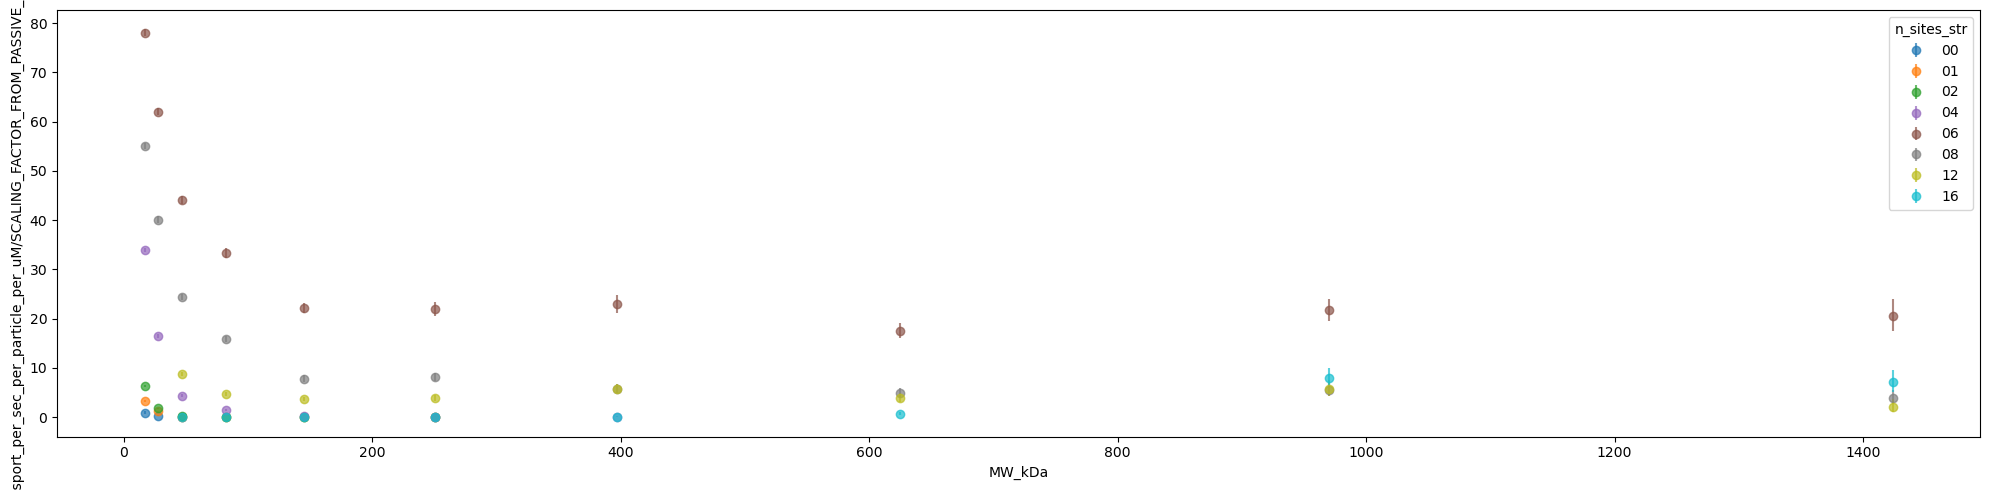

In [11]:
# Create the plot
fig, ax = plt.subplots(figsize=(20, 5))

# Prepare data
x = slice['MW_kDa']
y = slice['transport_per_sec_per_particle_per_uM'] / SCALING_FACTOR_FROM_PASSIVE_EXP + 0.01
y_low = slice['transport_per_sec_per_particle_per_uM_95low'] / SCALING_FACTOR_FROM_PASSIVE_EXP + 0.005
y_high = slice['transport_per_sec_per_particle_per_uM_95high'] / SCALING_FACTOR_FROM_PASSIVE_EXP + 0.01

# Get unique n_sites values for color mapping
unique_sites = slice['n_sites_str'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_sites)))

# Plot each group with different colors
for i, site in enumerate(unique_sites):
    mask = slice['n_sites_str'] == site
    ax.errorbar(x[mask], y[mask], 
                yerr=[y[mask] - y_low[mask], y_high[mask] - y[mask]],
                fmt='o', color=colors[i], label=site, alpha=0.7)

ax.set_xlabel('MW_kDa')
ax.set_ylabel('transport_per_sec_per_particle_per_uM/SCALING_FACTOR_FROM_PASSIVE_EXP+0.01')
ax.legend(title='n_sites_str')
plt.tight_layout()
plt.show()

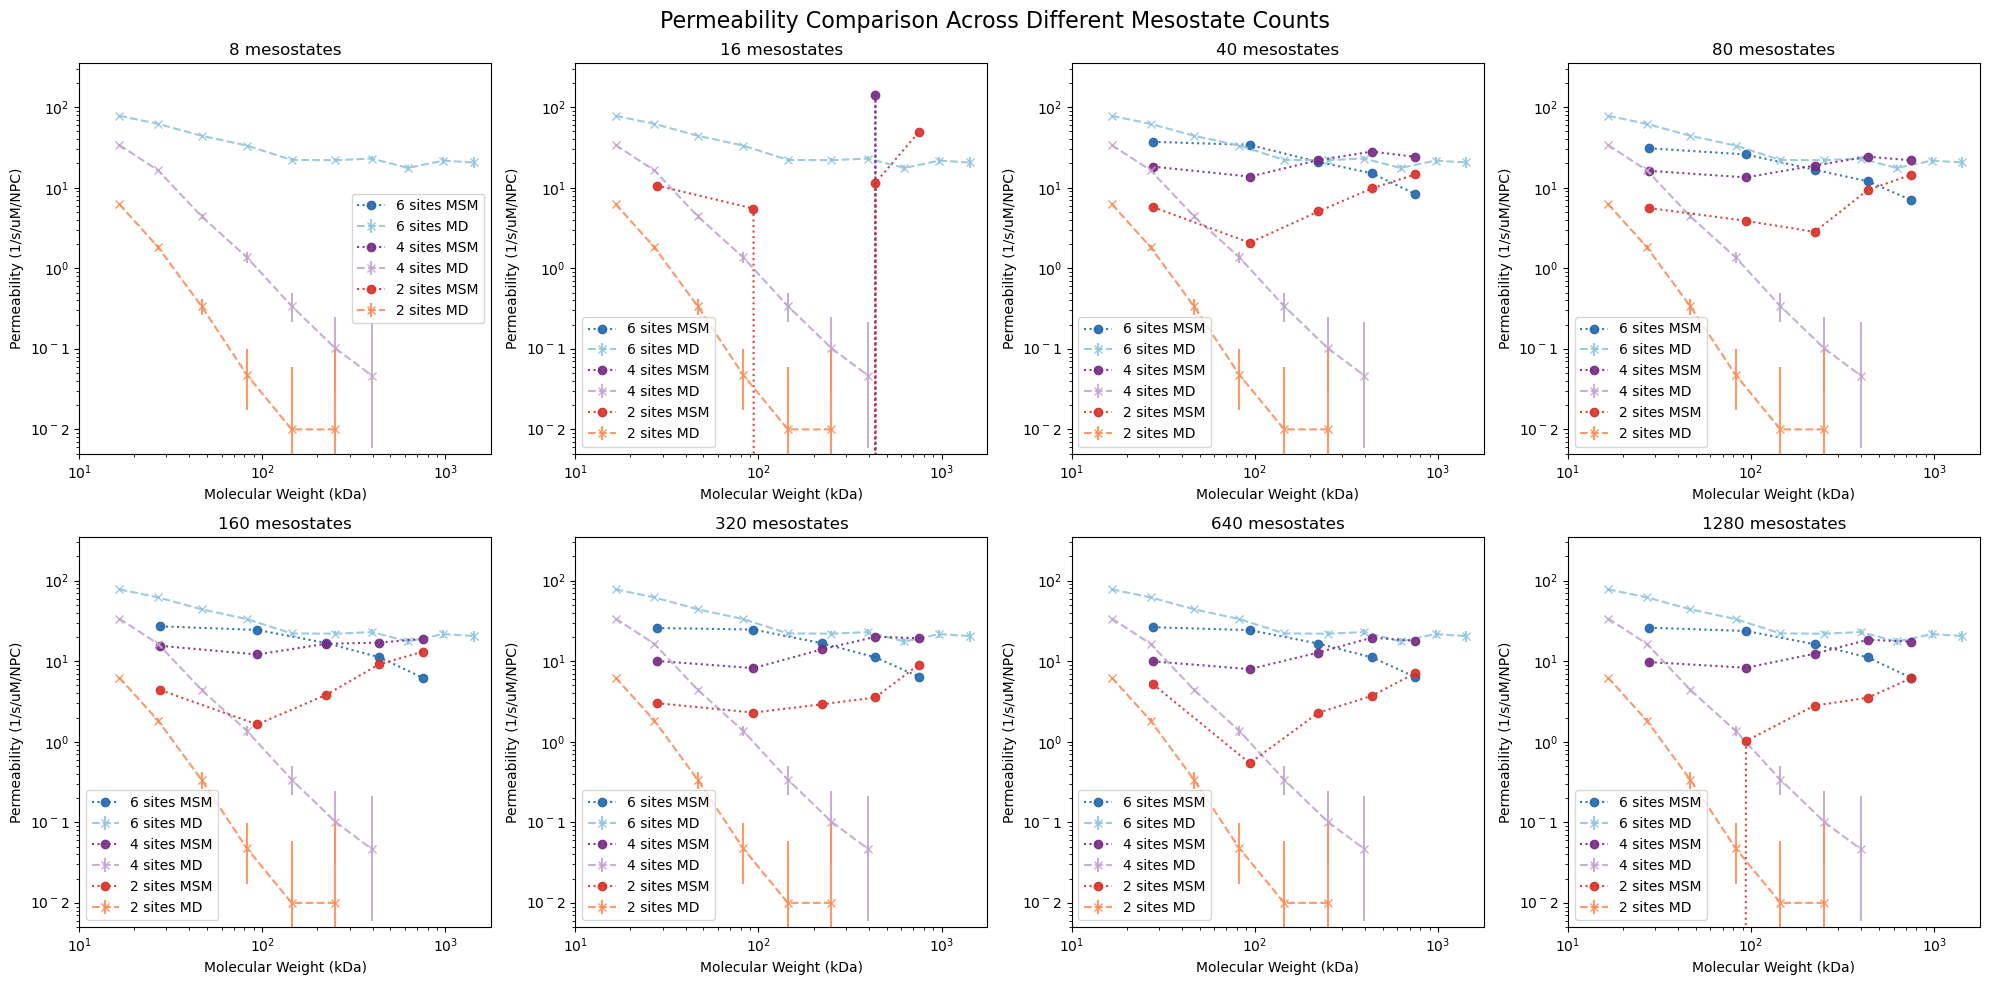

In [14]:



fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()  # Make it easier to iterate

for i, n_clusters in enumerate([8, 16, 40, 80, 160, 320, 640, 1280]):
    permeabilities_means = {}
    permeabilities_stds = {}
    for sites in [2, 4, 6]:
        with open(f"data/ntr_variants/{sites}_sites/permeabilities/permeabilities-{n_clusters}clusters.pickle", "rb") as f:
            permeabilities_means[sites] = pickle.load(f)
        # with open(f"data/ntr_variants/{sites}_sites/bmsm_permeabilities/std-{n_clusters}clusters.pickle", "rb") as f:
        #     permeabilities_stds[sites] = pickle.load(f)
            
    ax = axes[i]
    
    msm_colors = ["#2166ac", "#762a83", "#d73027"]
    md_colors = ["#92c5de", "#c2a5cf", "#fc8d59"]
    for i, sites in enumerate([6, 4, 2]):
        ax.errorbar(kdas, np.array(permeabilities_means[sites]) / (SCALING_FACTOR_FROM_PASSIVE_EXP - 100),
                    # yerr= 1.96 * np.array(permeabilities_stds[sites]) / SCALING_FACTOR_FROM_PASSIVE_EXP,
                    marker='o',
                label=f'{sites} sites MSM', color=msm_colors[i], alpha=0.9, linestyle=':')
        mask = slice['n_sites'] == sites
        ax.errorbar(x[mask], y[mask], 
                    yerr=[y[mask] - y_low[mask], y_high[mask] - y[mask]],
                    fmt='x--', color=md_colors[i], label=f'{sites} sites MD', alpha=0.9)


    
    # x axis
    ax.set_xlabel('Molecular Weight (kDa)')
    # ax.set_xlim(kdas[0], kdas[-1]) 
    ax.set_xscale('log')
    ax.set_xticks([10**1, 10**2, 10**3])
    ax.set_xticklabels([r'$10^1$', r'$10^2$', r'$10^3$'])
    
    # y axis
    ax.set_ylabel('Permeability (1/s/uM/NPC)')
    ax.set_yscale('log')
    ax.set_yticks([10**-2, 10**-1, 10**0, 10**1, 10**2, 10**3])
    ax.set_yticklabels([r'$10^-2$' ,r'$10^-1$', r'$10^0$', r'$10^1$', r'$10^2$', r'$10^3$'])
    ax.set_ylim([0.005, 350])

    ax.set_title(f"{n_clusters} mesostates")
    ax.legend()


plt.suptitle("Permeability Comparison Across Different Mesostate Counts", fontsize=16)
plt.tight_layout()
plt.show()

/tmp/ipykernel_275028/1964403716.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


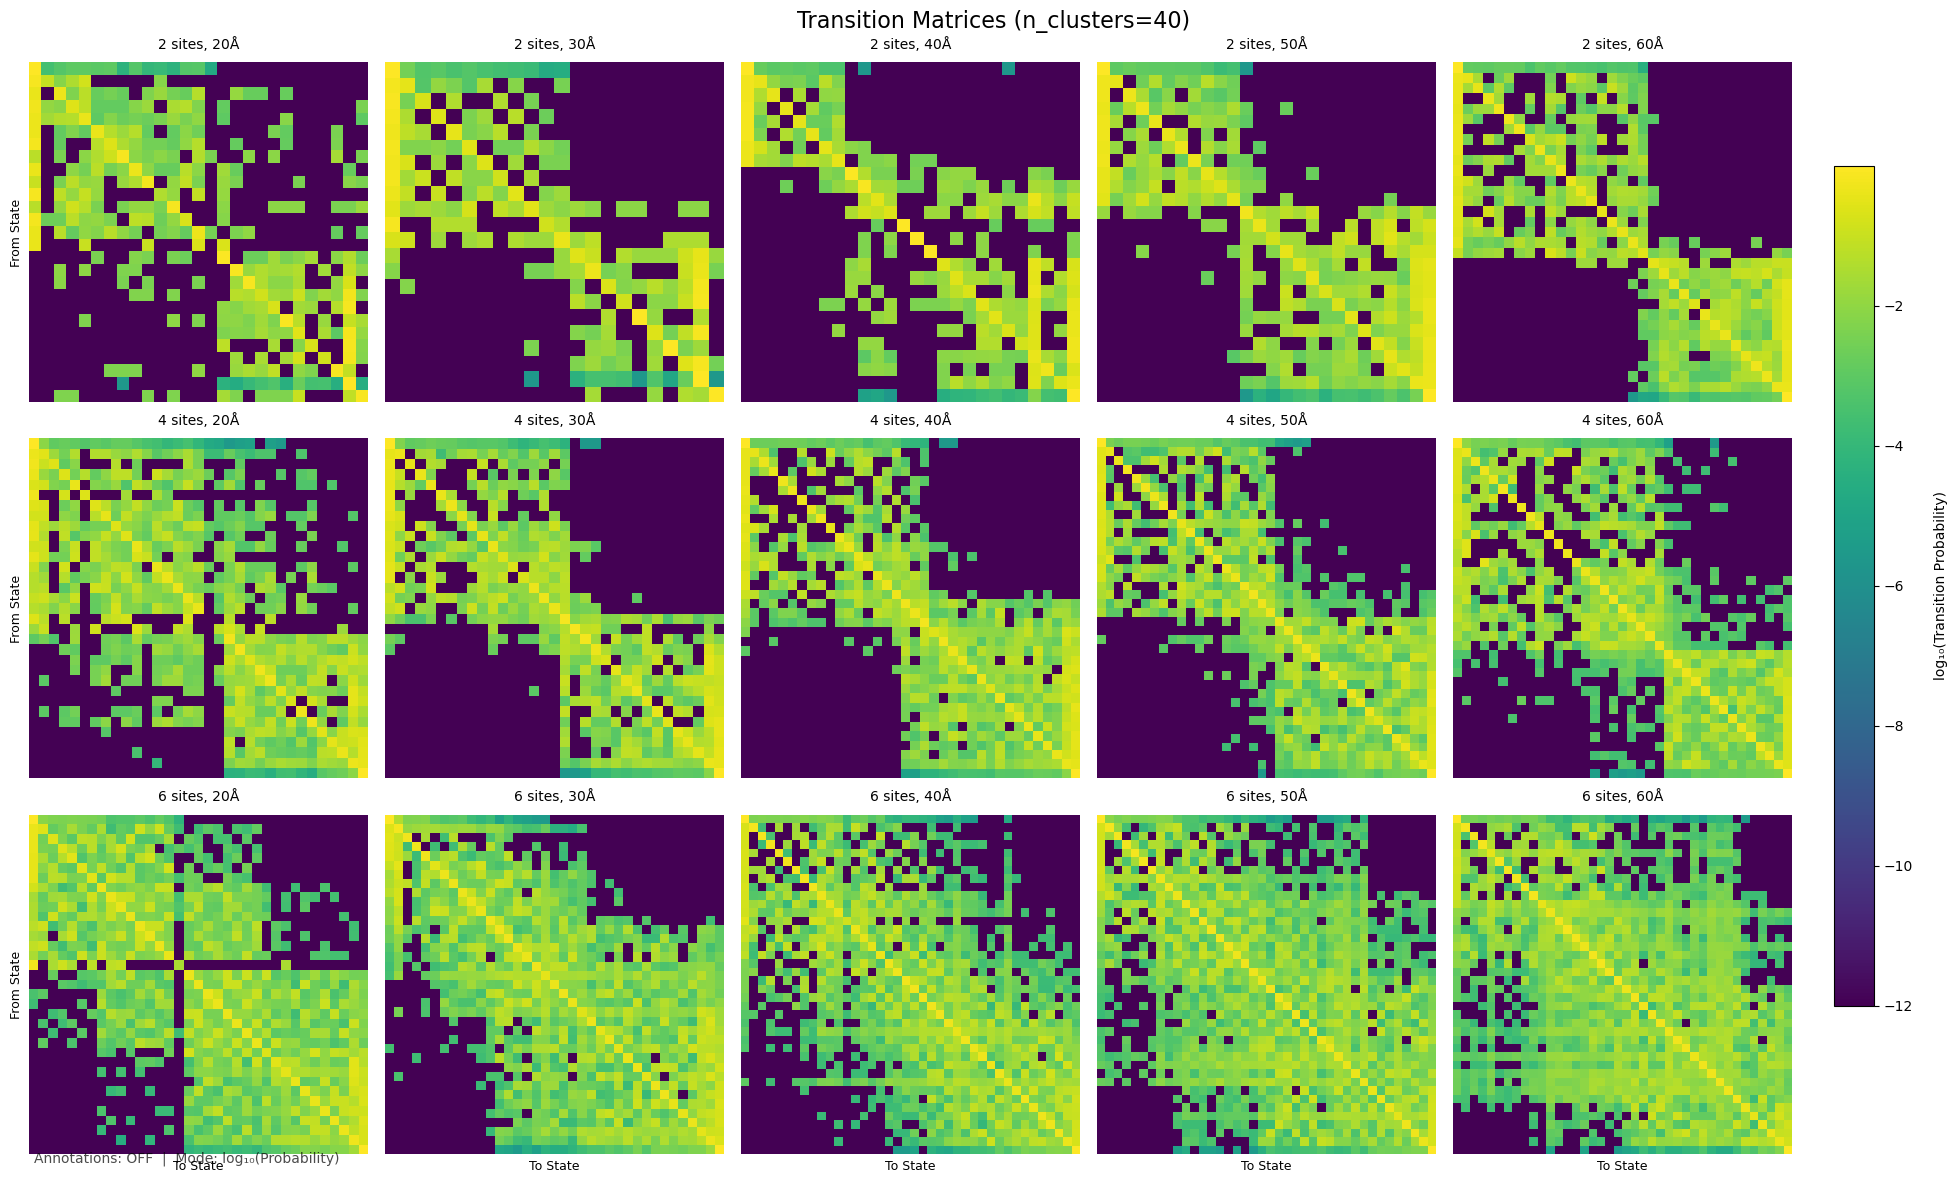


Summary:
Annotations: Disabled
Mode: log10(Probability)
Color scale: [-12.00, -0.00]
2 sites: 5 matrices loaded for radii [20, 30, 40, 50, 60]
4 sites: 5 matrices loaded for radii [20, 30, 40, 50, 60]
6 sites: 5 matrices loaded for radii [20, 30, 40, 50, 60]


In [10]:
# Plot transition matrices for 2, 4, and 6 sites in a 3x5 grid
import math
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuration
show_annotations = False  # Toggle to show/hide numbers on matrices
sites_list = [2, 4, 6]   # Sites to analyze
n_clusters = 40    # Number of clusters

# NEW: Toggle to show log10(Pij/Pji) instead of log10(probability)
use_log_ratio = False  # False: show log10(probabilities), True: show log10(Pij/Pji)
EPS = 1e-12  # small epsilon to avoid log/div-by-zero

# Assume radii is defined elsewhere in your code
# radii = [your_radii_list]  # Make sure this is defined

def load_transition_matrices(sites, radii, n_clusters):
    """Load transition matrices for a given number of sites"""
    tms = []
    available_radii = []
    
    for radius in radii:
        path = f"data/ntr_variants/{sites}_sites/{radius}_radius/transition_matrices/218pca-{n_clusters}clusters.pickle"
        if not os.path.exists(path):
            print(f"WARNING: missing file: {path}")
            continue
            
        with open(path, "rb") as f:
            tm = pickle.load(f)
        tms.append(tm)
        available_radii.append(radius)
    
    if not tms:
        print(f"No transition matrices loaded for {sites} sites")
        return [], []
    
    # Verify all are square and same size
    sizes = {tm.shape for tm in tms}
    if len(sizes) > 1:
        print(f"WARNING: Inconsistent TM shapes for {sites} sites: {sizes}")
    
    return tms, available_radii

def annotate_heatmap(ax, matrix, fmt="{:.3f}", fontsize=4, color="white"):
    """Add annotations to heatmap"""
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = matrix[i, j]
            ax.text(j + 0.5, i + 0.5, fmt.format(val), 
                   ha='center', va='center', fontsize=fontsize, color=color)

# Load data for all sites
all_data = {}
for sites in sites_list:
    tms, available_radii = load_transition_matrices(sites, radii, n_clusters)
    all_data[sites] = (tms, available_radii)

# Calculate global color scale across all matrices
all_matrices = []
for sites in sites_list:
    tms, _ = all_data[sites]
    all_matrices.extend(tms)

if all_matrices:
    if use_log_ratio:
        # log10(Pij/Pji) = log10(Pij+eps) - log10(Pji+eps)
        transformed = [np.log10((tm + EPS) / (tm.T + EPS)) for tm in all_matrices]
        colorbar_label = 'log₁₀(Pij/Pji)'
    else:
        transformed = [np.log10(tm + EPS) for tm in all_matrices]  # Add small value to avoid log(0)
        colorbar_label = 'log₁₀(Transition Probability)'
    vmin = min(mat.min() for mat in transformed)
    vmax = max(mat.max() for mat in transformed)
else:
    raise FileNotFoundError("No transition matrices loaded. Check file paths and radii.")

# Create figure with 3 rows (sites) and 5 columns (radii)
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle(f'Transition Matrices (n_clusters={n_clusters})', fontsize=16, y=0.98)

# Plot matrices
for row_idx, sites in enumerate(sites_list):
    tms, available_radii = all_data[sites]
    
    for col_idx in range(5):  # 5 columns
        ax = axes[row_idx, col_idx]
        
        if col_idx < len(tms):
            # Plot transition matrix
            tm = tms[col_idx]
            radius = available_radii[col_idx]
            
            # Choose what to display
            if use_log_ratio:
                disp_matrix = np.log10((tm + EPS) / (tm.T + EPS))
            else:
                disp_matrix = np.log10(tm + EPS)  # better visualization
            
            # Create heatmap using seaborn
            sns.heatmap(disp_matrix, 
                       ax=ax, 
                       cmap='viridis',
                       vmin=vmin, 
                       vmax=vmax,
                       square=True,
                       cbar=False,  # We'll add a shared colorbar later
                       xticklabels=False,
                       yticklabels=False)
            
            # Add annotations if enabled
            if show_annotations:
                # For ratio mode, annotate the log-ratio; otherwise annotate raw probabilities
                if use_log_ratio:
                    annotate_heatmap(ax, disp_matrix, fmt="{:.2f}", fontsize=6, color="white")
                else:
                    annotate_heatmap(ax, tm, fmt="{:.3f}", fontsize=6, color="white")
            
            # Set title and labels
            ax.set_title(f'{sites} sites, {radius}Å', fontsize=10, pad=10)
            
            if col_idx == 0:  # First column
                ax.set_ylabel('From State', fontsize=9)
            if row_idx == 2:  # Bottom row
                ax.set_xlabel('To State', fontsize=9)
                
        else:
            # Empty subplot for missing data
            ax.axis('off')
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=12, alpha=0.5)

# Add shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label(colorbar_label, rotation=90, labelpad=15)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(right=0.9)

# Add toggle information
toggle_text = (
    f"Annotations: {'ON' if show_annotations else 'OFF'}  |  "
    f"Mode: {'log₁₀(Pij/Pji)' if use_log_ratio else 'log₁₀(Probability)'}"
)
fig.text(0.02, 0.02, toggle_text, fontsize=10, alpha=0.7)

plt.show()

# Print summary information
print(f"\nSummary:")
print(f"Annotations: {'Enabled' if show_annotations else 'Disabled'}")
print(f"Mode: {'log10(Pij/Pji)' if use_log_ratio else 'log10(Probability)'}")
print(f"Color scale: [{vmin:.2f}, {vmax:.2f}]")
for sites in sites_list:
    tms, available_radii = all_data[sites]
    print(f"{sites} sites: {len(tms)} matrices loaded for radii {available_radii}")

In [ ]:
radii = [10, 14, 18, 22, 26]
n_sites = [2, 4, 6]


In [19]:
print("rmf_cat -f", end=" ")
for i in range(40000, 50000, 100):
    print(f"{i}.movie.rmf", end=" ")
print("merged.rmf", end="")

rmf_cat -f 40000.movie.rmf 40100.movie.rmf 40200.movie.rmf 40300.movie.rmf 40400.movie.rmf 40500.movie.rmf 40600.movie.rmf 40700.movie.rmf 40800.movie.rmf 40900.movie.rmf 41000.movie.rmf 41100.movie.rmf 41200.movie.rmf 41300.movie.rmf 41400.movie.rmf 41500.movie.rmf 41600.movie.rmf 41700.movie.rmf 41800.movie.rmf 41900.movie.rmf 42000.movie.rmf 42100.movie.rmf 42200.movie.rmf 42300.movie.rmf 42400.movie.rmf 42500.movie.rmf 42600.movie.rmf 42700.movie.rmf 42800.movie.rmf 42900.movie.rmf 43000.movie.rmf 43100.movie.rmf 43200.movie.rmf 43300.movie.rmf 43400.movie.rmf 43500.movie.rmf 43600.movie.rmf 43700.movie.rmf 43800.movie.rmf 43900.movie.rmf 44000.movie.rmf 44100.movie.rmf 44200.movie.rmf 44300.movie.rmf 44400.movie.rmf 44500.movie.rmf 44600.movie.rmf 44700.movie.rmf 44800.movie.rmf 44900.movie.rmf 45000.movie.rmf 45100.movie.rmf 45200.movie.rmf 45300.movie.rmf 45400.movie.rmf 45500.movie.rmf 45600.movie.rmf 45700.movie.rmf 45800.movie.rmf 45900.movie.rmf 46000.movie.rmf 46100.movie.r